<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Rede_Neural_Multilayer_Perceptron_MLP_(Regress%C3%A3o).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import sklearn.datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

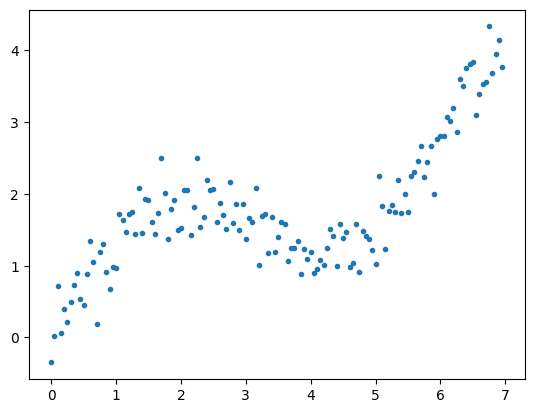

(140,)


In [3]:
X = np.arange(0,7,0.05)
Y = np.sin(X) + 0.3*np.random.randn(X.shape[0]) + 0.5*X
plt.plot(X,Y, '.')
plt.show()
print(X.shape)

(22, 1)
(6, 1)
(112, 1)


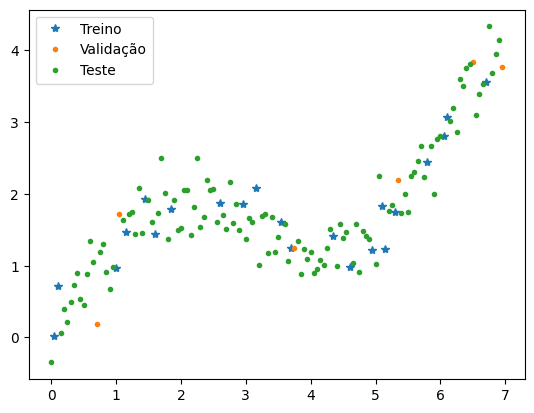

In [4]:
X = X.reshape((-1, 1))
Y = Y.reshape((-1, 1))

# Separação desenvolvimento (20) e teste (80)
X_dev, X_test, Y_dev, Y_test = train_test_split(X, Y, test_size=0.8, random_state=42)

# Separação desenvolvimento (80%) e validação (20%)
X_train, X_val, Y_train, Y_val = train_test_split(X_dev, Y_dev, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

plt.plot(X_train, Y_train, '*', label='Treino')
plt.plot(X_val, Y_val, '.', label='Validação')
plt.plot(X_test, Y_test, '.', label='Teste')
plt.legend()
plt.show()

In [5]:
x_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(Y_train)

x_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(Y_val)

x_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(Y_test)

In [6]:
# verificando disponibilidade da GPU

device = torch.devide.cuda() if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cpu')

In [10]:
class MLPin(nn.Module):
  def __init__(self, input_dim, output_dim):
    super(MLPin, self). __init__()
    self.rede = nn.Sequential(
        nn.Linear(input_dim, output_dim),
    )

  def forward(self, x):
    out = self.rede(x)
    return out

In [11]:
input_dim = 1 # número de atributos do Iris
output_dim = 1 # número de classes

modeloLin = MLPin(input_dim, output_dim)


In [12]:
from torchsummary import summary

print(modeloLin)
summary(modeloLin, (100,1))

MLPin(
  (rede): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 100, 1]               2
Total params: 2
Trainable params: 2
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [13]:
eta = 0.02
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(modeloLin.parameters(),lr=eta)

In [14]:
def train_network(model, optimizer,loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses):
  for epoch in range(num_epochs):
    # zerando os gradientes da época anterior
    optimizer.zero_grad()

    #fase de propagação
    output_train = model(x_train)

    #cálculo do erro (função de custo - loss function)
    loss_train = loss_function(output_train, y_train)

    # fase de retropropagação
    loss_train.backward()

    #atualização dos parâmetros
    optimizer.step()

    # avaliando o modelo com o conjunto de validação
    output_val = model(x_val)
    loss_val = loss_function(output_val, y_val)

    train_losses[epoch] = loss_train.item()
    val_losses[epoch] = loss_val.item()

    if (epoch + 1) % 1000 == 0:
      print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {loss_train.item():.4f}, Val Loss: {loss_val.item():.4f}")

In [15]:
num_epochs = 5000
train_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

train_network(modeloLin, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses)

Epoch 1000/5000, Train Loss: 0.3289, Val Loss: 0.7683
Epoch 2000/5000, Train Loss: 0.3289, Val Loss: 0.7683
Epoch 3000/5000, Train Loss: 0.3289, Val Loss: 0.7683
Epoch 4000/5000, Train Loss: 0.3289, Val Loss: 0.7683
Epoch 5000/5000, Train Loss: 0.3289, Val Loss: 0.7683


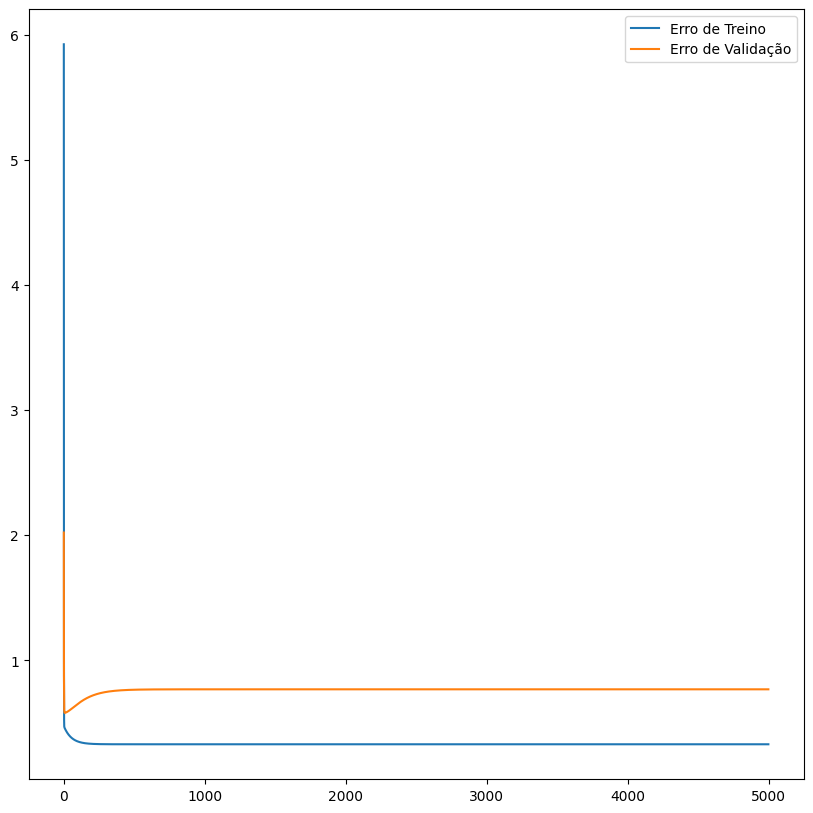

In [16]:
plt.figure(figsize=(10, 10))
plt.plot(train_losses, label='Erro de Treino')
plt.plot(val_losses, label='Erro de Validação')
plt.legend()
plt.show()

In [17]:
predictions_train = []
predictions_val = []
predictions_test = []

with torch.no_grad():
  predictions_train = modeloLin(x_train)
  predictions_val = modeloLin(x_val)
  predictions_test = modeloLin(x_test)

erro_train = loss_function(predictions_train, y_train)
erro_val = loss_function(predictions_val, y_val)
erro_test = loss_function(predictions_test, y_test)

print(f"Erro de Treino: {erro_train}")
print(f"Erro de Validação: {erro_val}")
print(f"Erro de Teste: {erro_test}")

Erro de Treino: 0.32889002561569214
Erro de Validação: 0.7683276534080505
Erro de Teste: 0.42557403445243835


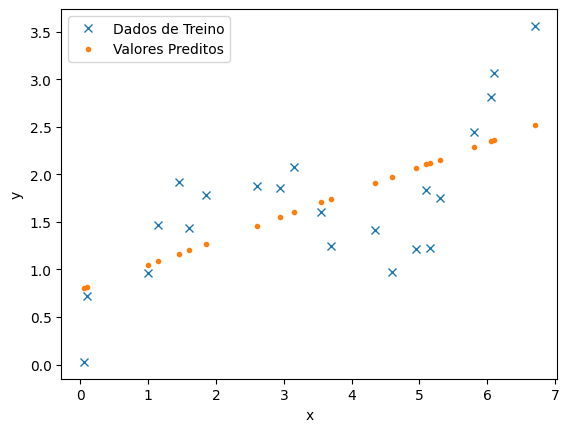

In [18]:
plt.plot(x_train, y_train, 'x', label='Dados de Treino')
plt.plot(x_train, predictions_train, '.', label='Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

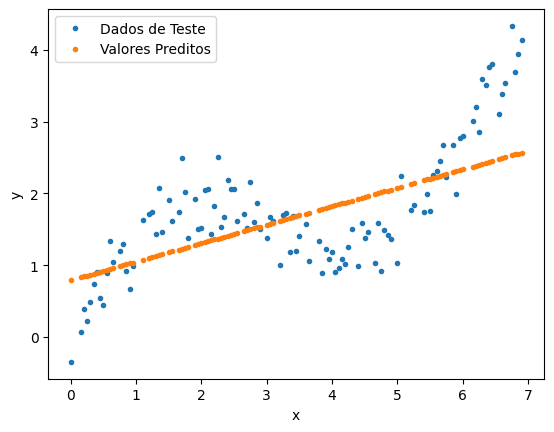

In [19]:
plt.plot(x_test, y_test, '.', label='Dados de Teste')
plt.plot(x_test, predictions_test, '.', label='Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

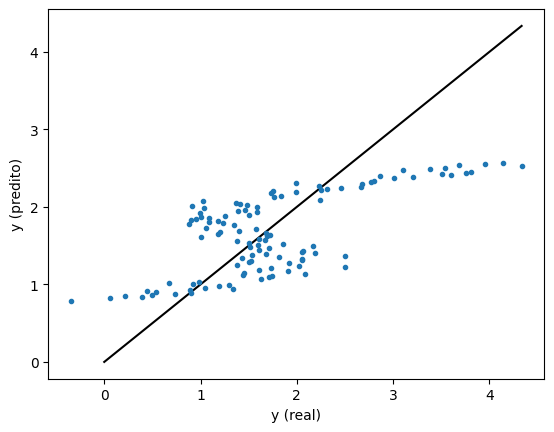

In [20]:
plt.plot([0, torch.max(y_test)],[0, torch.max(y_test)], 'black')
plt.plot(y_test, predictions_test, '.')
plt.xlabel('y (real)')
plt.ylabel('y (predito)')
plt.show()

In [22]:
class MLP(nn.Module):
  def __init__(self, input_dim, output_dim):
    super(MLP, self).__init__()
    self.rede = nn.Sequential(
        nn.Linear(input_dim, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, output_dim),
    )

  def forward(self, x):
    out = self.rede(x)
    return out


In [23]:
input_dim = 1 # número de atributos do Iris
output_dim = 1 # número de classes

modelo = MLP(input_dim, output_dim)

In [24]:
from torchsummary import summary

print(modelo)
summary(modelo, (100,1))

MLP(
  (rede): Sequential(
    (0): Linear(in_features=1, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1             [-1, 100, 512]           1,024
              ReLU-2             [-1, 100, 512]               0
            Linear-3             [-1, 100, 256]         131,328
              ReLU-4             [-1, 100, 256]               0
            Linear-5             [-1, 100, 128]          32,896
              ReLU-6             [-1, 100, 128]               0
            Linear-7              [-1, 100, 64]           8,256
              ReLU-8  

In [25]:
eta = 0.02
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(modelo.parameters(),lr=eta)

In [26]:
x_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(Y_train)

x_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(Y_val)

x_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(Y_test)

In [27]:
device = torch.devide.cuda() if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cpu')

In [28]:
def train_network(model, optimizer,loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses):
  for epoch in range(num_epochs):
    # zerando os gradientes da época anterior
    optimizer.zero_grad()

    # fase de propagação
    output_train = model(x_train)

    #cálculo do erro (função de custo - loss function)
    loss_train = loss_function(output_train, y_train)

    # fase de retropropagação
    loss_train.backward()

    # atualização dos pesos da rede
    optimizer.step()

    # avaliando o modelo com o conjunto de validação
    output_val = model(x_val)
    loss_val = loss_function(output_val, y_val)

    train_losses[epoch] = loss_train.item()
    val_losses[epoch] = loss_val.item()

    if (epoch + 1) % 1000 == 0:
      print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {loss_train.item():.4f}, Val Loss: {loss_val.item():.4f}")

In [29]:
num_epochs = 20000
train_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

train_network(modelo, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses)

Epoch 1000/20000, Train Loss: 0.2370, Val Loss: 0.2265
Epoch 2000/20000, Train Loss: 0.1777, Val Loss: 0.1834
Epoch 3000/20000, Train Loss: 0.0744, Val Loss: 0.1577
Epoch 4000/20000, Train Loss: 0.1494, Val Loss: 0.1637
Epoch 5000/20000, Train Loss: 0.0569, Val Loss: 0.3491
Epoch 6000/20000, Train Loss: 0.0337, Val Loss: 0.2442
Epoch 7000/20000, Train Loss: 0.0419, Val Loss: 0.3055
Epoch 8000/20000, Train Loss: 0.0283, Val Loss: 0.1644
Epoch 9000/20000, Train Loss: 0.0233, Val Loss: 0.2099
Epoch 10000/20000, Train Loss: 0.0230, Val Loss: 0.1853
Epoch 11000/20000, Train Loss: 0.0232, Val Loss: 0.1722
Epoch 12000/20000, Train Loss: 0.0266, Val Loss: 0.1894
Epoch 13000/20000, Train Loss: 0.0337, Val Loss: 0.1829
Epoch 14000/20000, Train Loss: 0.0202, Val Loss: 0.2632
Epoch 15000/20000, Train Loss: 0.0211, Val Loss: 0.2886
Epoch 16000/20000, Train Loss: 0.0176, Val Loss: 0.2032
Epoch 17000/20000, Train Loss: 0.0159, Val Loss: 0.2031
Epoch 18000/20000, Train Loss: 0.0209, Val Loss: 0.2936
E

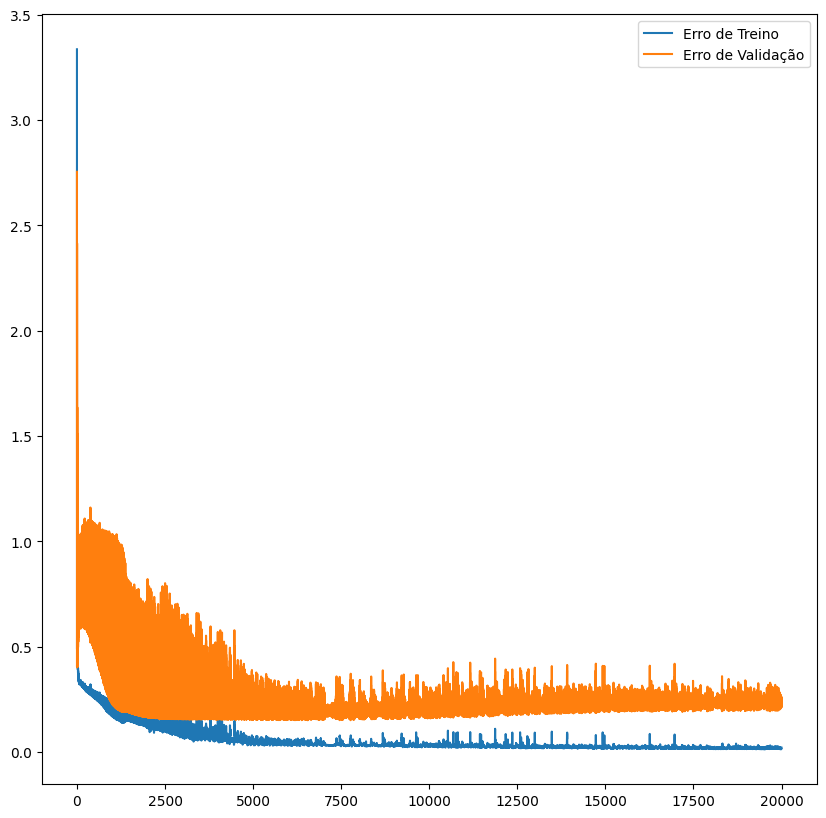

In [30]:
plt.figure(figsize=(10, 10))
plt.plot(train_losses, label='Erro de Treino')
plt.plot(val_losses, label='Erro de Validação')
plt.legend()
plt.show()

In [31]:
predictions_train = []
predictions_val = []
predictions_test = []

with torch.no_grad():
  predictions_train = modelo(x_train)
  predictions_val = modelo(x_val)
  predictions_test = modelo(x_test)

erro_train = loss_function(predictions_train, y_train)
erro_val = loss_function(predictions_val, y_val)
erro_test = loss_function(predictions_test, y_test)

print(f"Erro de Treino: {erro_train}")
print(f"Erro de Validação: {erro_val}")
print(f"Erro de Teste: {erro_test}")

Erro de Treino: 0.018171748146414757
Erro de Validação: 0.21420438587665558
Erro de Teste: 0.11226708441972733


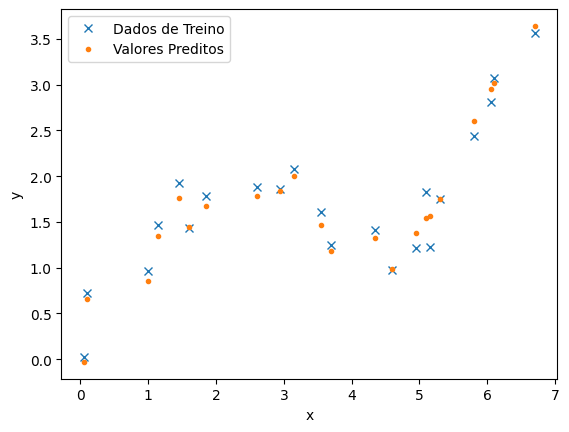

In [32]:
plt.plot(x_train, y_train, 'x', label='Dados de Treino')
plt.plot(x_train, predictions_train, '.', label='Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

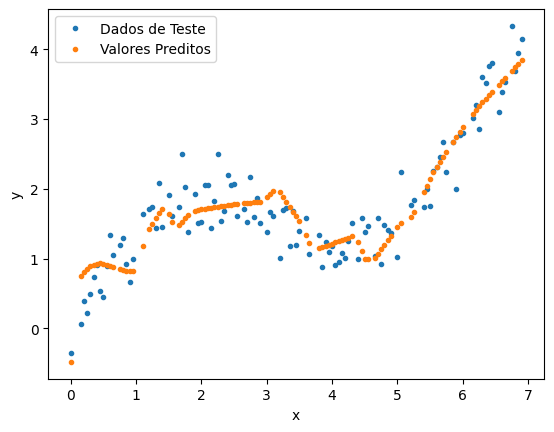

In [33]:
plt.plot(x_test, y_test, '.', label='Dados de Teste')
plt.plot(x_test, predictions_test, '.', label='Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

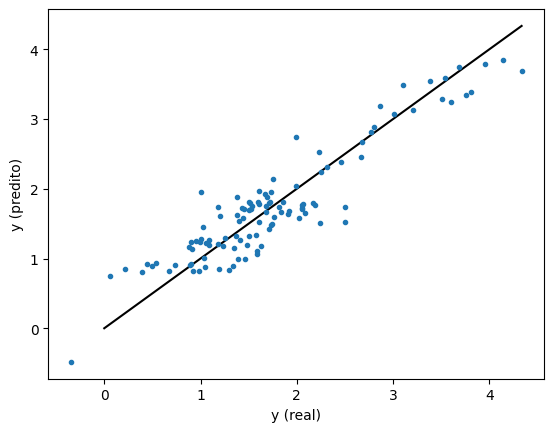

In [34]:
plt.plot([0, torch.max(y_test)],[0, torch.max(y_test)], 'black')
plt.plot(y_test, predictions_test, '.')
plt.xlabel('y (real)')
plt.ylabel('y (predito)')
plt.show()